## Part B: Dataset Understanding & Preparation

In [1]:
import pandas as pd

In [2]:
data = pd.read_csv('dataset/Customer_Dataset.csv')

##### Identify input features and target variable

In [3]:
data.columns

Index(['customer_id', 'age', 'gender', 'region', 'employment_type',
       'annual_income_inr', 'credit_score', 'credit_utilization_ratio',
       'missed_payments_12m', 'avg_late_payment_days',
       'monthly_transaction_count', 'monthly_spend_inr',
       'cash_advance_count_6m', 'complaints_last_6m',
       'failed_login_attempts_3m', 'account_tenure_months',
       'last_transaction_date', 'debt_balance_inr', 'risk_status'],
      dtype='object')

In [4]:
X = data[['credit_score','credit_utilization_ratio','missed_payments_12m','avg_late_payment_days','annual_income_inr','cash_advance_count_6m','failed_login_attempts_3m','debt_balance_inr']]

In [5]:
y = data['risk_status']

##### Identify missing values and apply KNN Imputer for multivariate imputation

In [6]:
X.isnull().sum()

credit_score                216
credit_utilization_ratio    147
missed_payments_12m           0
avg_late_payment_days         0
annual_income_inr           166
cash_advance_count_6m         0
failed_login_attempts_3m      0
debt_balance_inr              0
dtype: int64

In [7]:
from sklearn.impute import KNNImputer

In [8]:
knn = KNNImputer(n_neighbors = 5)

In [9]:
X = pd.DataFrame(knn.fit_transform(X),columns=X.columns)

In [10]:
X.isnull().sum()

credit_score                0
credit_utilization_ratio    0
missed_payments_12m         0
avg_late_payment_days       0
annual_income_inr           0
cash_advance_count_6m       0
failed_login_attempts_3m    0
debt_balance_inr            0
dtype: int64

In [11]:
X.head()

,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,annual_income_inr,cash_advance_count_6m,failed_login_attempts_3m,debt_balance_inr
0,659.0,0.120,1.0,2.2,82242.0,0.0,4.0,87273.0
1,647.0,0.337,1.0,1.5,32769.0,1.0,1.0,20600.0
2,727.0,0.175,0.0,3.9,39731.0,2.0,1.0,47565.0
3,553.0,0.472,7.0,23.3,38990.0,1.0,6.0,43803.0
4,732.0,0.418,1.0,9.8,41043.0,0.0,1.0,12008.0


##### Perform train-test split while maintaining class distribution

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [41]:
ss = StandardScaler()

In [42]:
X_ss = ss.fit_transform(X)

In [43]:
X_train,X_test,y_train,y_test = train_test_split(X_ss, y, test_size=0.2, random_state=42)

## Part C: Baseline Classification Model

##### Implement Logistic Regression as a baseline model

In [44]:
from sklearn.linear_model import LogisticRegression

In [45]:
lr = LogisticRegression(max_iter=1000,random_state=42)

In [46]:
lr.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [47]:
y_pred =lr.predict(X_test)

##### Generate and interpret:

* Confusion Matrix
* Accuracy Score
* Precision, Recall, F1-Score

In [18]:
from sklearn.metrics import (confusion_matrix,
    accuracy_score,
    classification_report)

In [19]:
cm = confusion_matrix(y_test,y_pred)
cm

array([[796,   0],
       [  2, 122]])

In [20]:
acc = accuracy_score(y_test,y_pred)
acc

0.9978260869565218

In [21]:
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       796
           1       1.00      0.98      0.99       124

    accuracy                           1.00       920
   macro avg       1.00      0.99      1.00       920
weighted avg       1.00      1.00      1.00       920



##### Identify Type-I and Type-II errors from the confusion matrix

In [22]:
tn,fp,fn,tp = cm.ravel()

In [23]:
print(f'Type 1 Error: {fp}')
print(f'Type 2 Error: {fn}')

Type 1 Error: 0
Type 2 Error: 2


## Part D: Handling Imbalanced Data

##### Demonstrate the impact of class imbalance on model performance

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

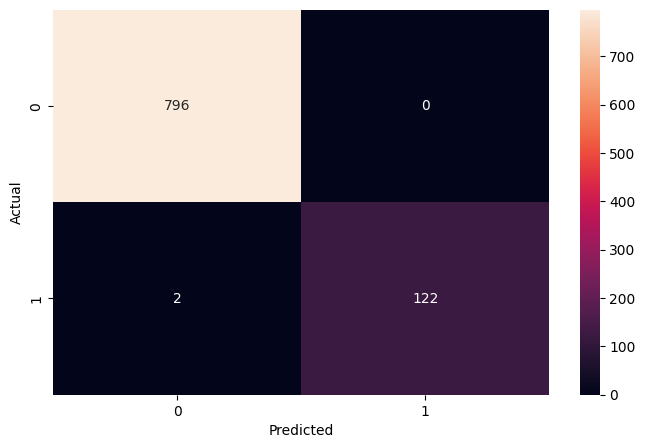

In [48]:
plt.figure(figsize=(8,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Although the dataset is imbalanced, the model achieved very high performance across all metrics, including a recall of 0.98 for the minority class.
This suggests that either the dataset is easily separable or there may be potential data leakage.
In typical imbalanced scenarios, models tend to perform poorly on the minority class, but in this case, the impact is minimal.

##### Apply the following techniques and retrain the model:

* Under-Sampling
* Over-Sampling
* SMOTE
* ADASYN

##### Compare performance before and after balancing using:

* Recall for minority class
* F1-Score
* AUC-ROC

In [55]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from sklearn.metrics import roc_auc_score

In [27]:
rus = RandomUnderSampler(random_state=42)
ros = RandomOverSampler(random_state=42)
smote = SMOTE(random_state=42)
ada = ADASYN(random_state=42)

In [49]:
X_rus,y_rus = rus.fit_resample(X_ss,y)
X_ros,y_ros = ros.fit_resample(X_ss,y)
X_smote,y_smote = smote.fit_resample(X_ss,y)
X_ada,y_ada = ada.fit_resample(X_ss,y)

In [58]:
# Random Under-Sampling
X_train, X_test, y_train, y_test = train_test_split(
    X_rus, y_rus, test_size=0.2, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_probs)

print(f"AUC-ROC Score: {auc_score:.4f}")
print(classification_report(y_test,pred))
print(confusion_matrix(y_test,pred))

AUC-ROC Score: 0.9997
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       115
           1       0.99      0.99      0.99       108

    accuracy                           0.99       223
   macro avg       0.99      0.99      0.99       223
weighted avg       0.99      0.99      0.99       223

[[114   1]
 [  1 107]]


In [59]:
# Random Over-Sampling
X_train, X_test, y_train, y_test = train_test_split(
    X_ros, y_ros, test_size=0.2, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_probs)

print(f"AUC-ROC Score: {auc_score:.4f}")
print(classification_report(y_test,pred))
print(confusion_matrix(y_test,pred))

AUC-ROC Score: 0.9996
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       820
           1       0.99      0.99      0.99       798

    accuracy                           0.99      1618
   macro avg       0.99      0.99      0.99      1618
weighted avg       0.99      0.99      0.99      1618

[[812   8]
 [  8 790]]


In [60]:
# SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X_smote, y_smote, test_size=0.2, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_probs)

print(f"AUC-ROC Score: {auc_score:.4f}")
print(classification_report(y_test,pred))
print(confusion_matrix(y_test,pred))

AUC-ROC Score: 0.9999
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       820
           1       1.00      0.99      0.99       798

    accuracy                           0.99      1618
   macro avg       0.99      0.99      0.99      1618
weighted avg       0.99      0.99      0.99      1618

[[817   3]
 [  6 792]]


In [61]:
# ADASYN
X_train, X_test, y_train, y_test = train_test_split(
    X_smote, y_smote, test_size=0.2, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_probs)

print(f"AUC-ROC Score: {auc_score:.4f}")
print(classification_report(y_test,pred))
print(confusion_matrix(y_test,pred))

AUC-ROC Score: 0.9999
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       820
           1       1.00      0.99      0.99       798

    accuracy                           0.99      1618
   macro avg       0.99      0.99      0.99      1618
weighted avg       0.99      0.99      0.99      1618

[[817   3]
 [  6 792]]


## Part E: Tree-Based Classification Models

##### Task 16: Implement Decision Tree Classifier

In [62]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
model = DecisionTreeClassifier(random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X_ss,y,test_size=0.2,random_state=42)

model.fit(X_train,y_train)

##### Task 17: Analyze overfitting by comparing training and testing performance

In [66]:
predict = model.predict(X_test)

In [68]:
print(classification_report(y_test,predict))
print(confusion_matrix(y_test,predict))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       796
           1       0.86      0.88      0.87       124

    accuracy                           0.96       920
   macro avg       0.92      0.93      0.92       920
weighted avg       0.96      0.96      0.96       920

[[778  18]
 [ 15 109]]


##### Task 18: Implement Random Forest Classifier

In [71]:
from sklearn.ensemble import RandomForestClassifier

In [72]:
model = RandomForestClassifier(random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X_ss,y,test_size=0.2,random_state=42)

model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

##### Task 19: Compare Decision Tree vs Random Forest in terms of accuracy and generalization

In [73]:
predict = model.predict(X_test)

In [74]:
print(classification_report(y_test,predict))
print(confusion_matrix(y_test,predict))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       796
           1       0.98      0.95      0.96       124

    accuracy                           0.99       920
   macro avg       0.98      0.97      0.98       920
weighted avg       0.99      0.99      0.99       920

[[793   3]
 [  6 118]]


The Random Forest classifier performs better than the Decision Tree in terms of accuracy and generalization.

While the Decision Tree tends to overfit the training data, Random Forest reduces overfitting by combining multiple trees (ensemble learning).

As a result, Random Forest provides more stable and reliable predictions on unseen data.

Therefore, Random Forest is selected as the better model for this problem.